In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import immunowave as iw
from immunowave_paper_utils import style_axes, colors, fontsize, linewidth, rc_params
from diffrax import SaveAt
from scipy.optimize import curve_fit
from functools import partial

In [2]:
linewidth = 3
fontsize = 24
markersize = 12
markeredgewidth = 2
rc_params["axes.linewidth"] = linewidth
rc_params["font.size"] = fontsize
mpl.rcParams.update(rc_params)
mpl.rcParams["pdf.fonttype"] = 42
sim_color = np.array([94, 45, 144]) / 255
d3_color = np.array([210, 85, 39]) / 255

In [3]:
path_to_data_2d = r"/home/brandon/Documents/Code/immunowave/data/2025_08_04_2D"
path_to_data_3d = r"/home/brandon/Documents/Code/immunowave/data/2025_08_01_3D_v2"

In [4]:
class State(iw.State):
    u: iw.ScalarField


class Model(iw.Model):
    KD: float
    n: float
    I: float
    k: float = 1.0
    γ: float = 1.0
    D: float = 1.0
    # Bandwidth adjustment for Dirac delta approximation (grid units)
    bw_adjust: float = 0.5

    def f(self, u):
        KD, n, k, γ = self.KD, self.n, self.k, self.γ
        return k * u.hill(KD, n) - γ * u

    def delta(self, u):
        """Helper function to approximate a Dirac delta as a Gaussian on the same grid as u."""
        σ = self.bw_adjust * u.h

        def gaussian(*coords):
            squared_dist = sum(coord**2 for coord in coords)
            return jnp.exp(-squared_dist / (2 * σ**2))

        result = iw.ScalarField(u.values.shape, u.lb, u.h, fn=gaussian)
        result /= result.integral()
        return result

    def __call__(self, t, state: State, args=None):
        u = state.u
        Δu = u.laplacian(bc="neumann")
        f = self.f
        I = self.I
        δ = self.delta(u)
        D = self.D

        dudt = D * Δu + f(u) + 2 * I * δ

        return State(dudt)

## Plot 

In [5]:
plt.close("all")

### comparison with numerics --- KD

In [5]:
def KD_scaling_theory(KD, c, n):
    return c * KD ** (n / (n - 1))


def fit_Ic_vs_KD_prefactor(KDs, Ics, n):
    p0 = [
        1,
    ]
    popt, pcov = curve_fit(partial(KD_scaling_theory, n=n), KDs, Ics, p0=p0)
    return popt[0]

In [8]:
%matplotlib qt
fig, axs = plt.subplots(1, 3, figsize=[16.56, 5.5])
"""plot"""
# d=2
with open(
    path_to_data_2d + "/KD_sweep.pkl",
    "rb",
) as f:
    KD_sweep_dict = pickle.load(f)
KDs = KD_sweep_dict["KD_grid"]
Ic_wave = KD_sweep_dict["Ic_grid"]
hill_coefficient = 4

ax = axs[0]
ax.clear()
# prefactor = fit_Ic_vs_KD_prefactor(KDs[KDs<0.02], Ic_wave[KDs<0.02], hill_coefficient)
# KDs_theory = np.logspace(np.log10(np.min(KDs)), np.log10(np.max(KDs)), 1000)
# tissue_theory = KD_scaling_theory(KDs_theory, prefactor, hill_coefficient)
# ax.plot(
#     KDs_theory,
#     tissue_theory,
#     "-",
#     linewidth=linewidth,
#     color=colors["wave"],
#     label="$\sim K_D^{n/(n-1)}$",
# )


ax.plot(
    KDs,
    Ic_wave,
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=sim_color,
    label="$d=2$",
)

# d=3
with open(
    path_to_data_3d + "/KD_sweep.pkl",
    "rb",
) as f:
    KD_sweep_dict = pickle.load(f)
KDs = KD_sweep_dict["KD_grid"]
Ic_wave = KD_sweep_dict["Ic_grid"]
hill_coefficient = 4

ax = axs[0]
# prefactor = fit_Ic_vs_KD_prefactor(KDs[KDs<0.02], Ic_wave[KDs<0.02], hill_coefficient)
# KDs_theory = np.logspace(np.log10(np.min(KDs)), np.log10(np.max(KDs)), 1000)
# tissue_theory = KD_scaling_theory(KDs_theory, prefactor, hill_coefficient)
# ax.plot(
#     KDs_theory,
#     tissue_theory,
#     "-",
#     linewidth=linewidth,
#     color=colors["wave"],
#     label="_none_",
# )


ax.plot(
    KDs,
    Ic_wave,
    marker="d",
    markersize=markersize,
    markerfacecolor=np.concatenate((d3_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=d3_color,
    label="$d=3$",
)

# scaling prediction
KDs_theory = np.logspace(-2, -1.5, 5)
prefactor = 1
scaling_theory = prefactor * KDs_theory ** (hill_coefficient / (hill_coefficient - 1))
ax.plot(
    KDs_theory,
    scaling_theory,
    "-",
    linewidth=linewidth,
    color=colors["wave"],
    label="$\sim K_D^{n/(n-1)}$",
)

ax.legend(fontsize=fontsize, loc="upper left")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"$I^{wave}_{c}$ (a.u.)", fontsize=fontsize)
ax.set_xlabel(
    "concentration scale \nof positive feedback, $K_D$ (a.u.)", fontsize=fontsize
)
# ax.set_ylim([2e-3, 5e-1])
ax.minorticks_off()
style_axes(ax, fontsize=fontsize)

<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9826/2577485065.py:87: SyntaxWarning: invalid escape sequence '\s'
  label="$\sim K_D^{n/(n-1)}$",


<Axes: xlabel='concentration scale \nof positive feedback, $K_D$ (a.u.)', ylabel='$I^{wave}_{c}$ (a.u.)'>

### plot n-dependent prefactor of Ic_wave

In [9]:
def Ic_mixed(KD, n):
    return 0.5 * (1 - 1 / n) * (1 / n) ** (1 / (n - 1)) * KD ** (n / (n - 1))

In [11]:
with open(
    path_to_data_2d + "/n_sweep.pkl",
    "rb",
) as f:
    hill_coeff_sweep_dict = pickle.load(f)
hill_coefficients = jnp.linspace(1.3, 5.0, 20)  # hill_coeff_sweep_dict["n_grid"]
Ic_wave = hill_coeff_sweep_dict["Ic_grid"]

Ic_wave / KD ** (hill_coefficients / (hill_coefficients - 1))

Array([2.50712981, 2.39397194, 2.29568234, 2.20918393, 2.13253199,
       2.06421471, 2.00330779, 1.94890455, 1.90000122, 1.85623921,
       1.81691125, 1.78152933, 1.74988676, 1.72115726, 1.69544773,
       1.67209222, 1.65108218, 1.63213041, 1.61484759, 1.59915022],      dtype=float64)

In [12]:
hill_coefficients

Array([1.3       , 1.49473684, 1.68947368, 1.88421053, 2.07894737,
       2.27368421, 2.46842105, 2.66315789, 2.85789474, 3.05263158,
       3.24736842, 3.44210526, 3.63684211, 3.83157895, 4.02631579,
       4.22105263, 4.41578947, 4.61052632, 4.80526316, 5.        ],      dtype=float64)

In [10]:
"""plot"""

ns = np.linspace(1.3, 5, 100)
KD = 0.01

# d=2
with open(
    path_to_data_2d + "/n_sweep.pkl",
    "rb",
) as f:
    hill_coeff_sweep_dict = pickle.load(f)
hill_coefficients = jnp.linspace(1.3, 5.0, 20)  # hill_coeff_sweep_dict["n_grid"]
Ic_wave = hill_coeff_sweep_dict["Ic_grid"]

ax = axs[1]
ax.clear()

ax.plot(
    hill_coefficients,
    Ic_wave / KD ** (hill_coefficients / (hill_coefficients - 1)),
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=sim_color,
    label="numerics",
)


# d=3
with open(
    path_to_data_3d + "/n_sweep.pkl",
    "rb",
) as f:
    hill_coeff_sweep_dict = pickle.load(f)
hill_coefficients = jnp.linspace(1.3, 5.0, 20)  # hill_coeff_sweep_dict["n_grid"]
Ic_wave = hill_coeff_sweep_dict["Ic_grid"]

ax = axs[1]

ax.plot(
    hill_coefficients,
    Ic_wave / KD ** (hill_coefficients / (hill_coefficients - 1)),
    marker="d",
    markersize=markersize,
    markerfacecolor=np.concatenate((d3_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=d3_color,
    label="_none_",
)


ax.set_xscale("linear")
ax.set_yscale("log")
ax.set_ylabel(r"$I^{wave}_{c}K_D^{-n/(n-1)}$ (a.u.)", fontsize=fontsize)
ax.set_xlabel("hill coefficient, $n$", fontsize=fontsize)
ax.set_ylim([1e0, 2e1])

# ax.set_ylim([1e-10, 1e-2])
# ax.set_yticks([1e-0, 1e1])
ax.minorticks_off()
style_axes(ax, fontsize=fontsize)

<Axes: xlabel='hill coefficient, $n$', ylabel='$I^{wave}_{c}K_D^{-n/(n-1)}$ (a.u.)'>

### plot g_d(n)

In [30]:
"""plot"""

ns = np.linspace(1.3, 5, 100)
KD = 0.01

# d=2
with open(
    path_to_data_2d + "/n_sweep.pkl",
    "rb",
) as f:
    hill_coeff_sweep_dict = pickle.load(f)
hill_coefficients = jnp.linspace(1.3, 5.0, 20)  # hill_coeff_sweep_dict["n_grid"]
Ic_wave = hill_coeff_sweep_dict["Ic_grid"]

ax = axs[2]
ax.clear()

ax.plot(
    hill_coefficients,
    Ic_wave
    / Ic_mixed(
        KD, hill_coefficients
    ),  # KD ** (hill_coefficients / (hill_coefficients - 1)),
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=sim_color,
    label="numerics",
)


# d=3
with open(
    path_to_data_3d + "/n_sweep.pkl",
    "rb",
) as f:
    hill_coeff_sweep_dict = pickle.load(f)
hill_coefficients = jnp.linspace(1.3, 5.0, 20)  # hill_coeff_sweep_dict["n_grid"]
Ic_wave = hill_coeff_sweep_dict["Ic_grid"]

ax = axs[2]

ax.plot(
    hill_coefficients,
    Ic_wave
    / Ic_mixed(
        KD, hill_coefficients
    ),  # KD ** (hill_coefficients / (hill_coefficients - 1)),
    marker="d",
    markersize=markersize,
    markerfacecolor=np.concatenate((d3_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=d3_color,
    label="_none_",
)


ax.set_xscale("linear")
ax.set_yscale("log")
# ax.set_ylabel(r"$I^{wave}_{c}K_D^{-n/(n-1)}$ (a.u.)", fontsize=fontsize)
ax.set_ylabel(r"$g_d(n)$", fontsize=fontsize)
ax.set_xlabel("hill coefficient, $n$", fontsize=fontsize)
# ax.set_ylim([1e0, 2e1])

# ax.set_ylim([1e-10, 1e-2])
# ax.set_yticks([1e-0, 1e1])
ax.minorticks_off()
style_axes(ax, fontsize=fontsize)

<Axes: xlabel='hill coefficient, $n$', ylabel='$g_d(n)$'>

In [31]:
fig.tight_layout()

In [33]:
plt.savefig(r"/home/brandon/Documents/Code/immunowave/plots/2025_08_21_higher_dims.pdf")

In [24]:
fig.get_size_inches()

array([16.56,  5.5 ])

<Axes: xlabel='hill coefficient, $n$', ylabel='$g_1(n)$'>

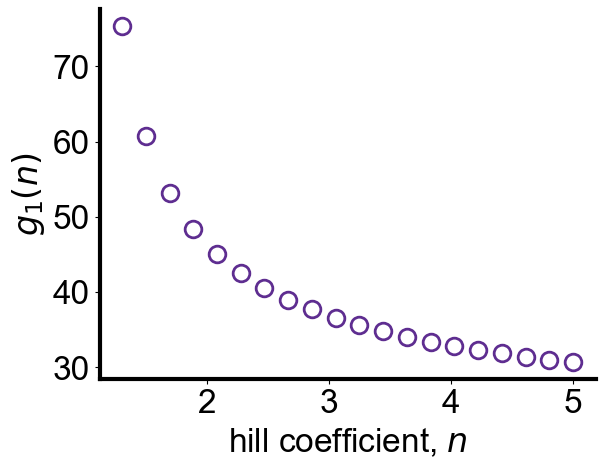

In [14]:
"""plot d=1"""

ns = np.linspace(1.3, 5, 100)
KD = 0.01
path_to_data_1d = r"/home/brandon/Documents/Code/immunowave/data/2025_07_28_updated_sims_will_notebook"
l_cell = 0.1

# d=1
with open(
    path_to_data_1d + "/n_sweep.pkl",
    "rb",
) as f:
    hill_coeff_sweep_dict = pickle.load(f)
hill_coefficients = jnp.linspace(1.3, 5.0, 20)  # hill_coeff_sweep_dict["n_grid"]
Ic_wave = hill_coeff_sweep_dict["Ic_grid"]

fig, ax = plt.subplots()
ax.clear()

ax.plot(
    hill_coefficients,
    Ic_wave / l_cell
    / Ic_mixed(
        KD, hill_coefficients
    ),  # KD ** (hill_coefficients / (hill_coefficients - 1)),
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=sim_color,
    label="numerics",
)


#
ax.set_xscale("linear")
ax.set_yscale("linear")
# ax.set_ylabel(r"$I^{wave}_{c}K_D^{-n/(n-1)}$ (a.u.)", fontsize=fontsize)
ax.set_ylabel(r"$g_1(n)$", fontsize=fontsize)
ax.set_xlabel("hill coefficient, $n$", fontsize=fontsize)
# ax.set_ylim([1e0, 2e1])

# ax.set_ylim([1e-10, 1e-2])
# ax.set_yticks([1e-0, 1e1])
ax.minorticks_off()
style_axes(ax, fontsize=fontsize)